# Basic Passband Communication System Using SSB Modulation

This notebook implements a complete single-sideband (SSB) passband communication chain:

1. a deterministic band-limited message $m(t)$;
2. SSB modulation using the Hilbert-transform phasing method;
3. an additive white Gaussian noise (AWGN) channel at controlled SNR;
4. coherent demodulation using a conventional low-pass filter;
5. analytic-signal demodulation using a Hilbert filter;
6. time-domain, autocorrelation, PSD, approximate-bandwidth, and error comparisons.

The modulation factors are
$$
\mu\in\{0.72,1.00,1.23\}.
$$
For ordinary DSB-LC AM, values above one can create envelope over-modulation. For the SSB suppressed-carrier model used as the main numerical chain here, $\mu$ is instead a linear sideband gain. Increasing $\mu$ increases transmit power and receiver SNR sensitivity, but it does not create envelope sign reversal by itself. When a carrier-transmitted SSB variant is plotted, the same warning applies: envelope interpretation is not the demodulation contract; coherent or analytic demodulation is the intended receiver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)

# Sampling and carrier parameters.
fs = 20_000
T = 0.25
t = np.arange(0, T, 1 / fs)
N = t.size
fc = 2_000
Ac = 1.0
mus = [0.72, 1.0, 1.23]
snr_db_values = [30, 10, 3]

# Message spectrum: finite, known baseband support.
message_freqs = np.array([45, 90, 140, 180], dtype=float)
message_amps = np.array([1.00, 0.55, 0.36, 0.24], dtype=float)
message_phases = np.array([0.2, -0.9, 1.4, -2.1], dtype=float)
message_bandwidth = float(np.max(message_freqs))
lowpass_cutoff = 1.35 * message_bandwidth
frequency_axis_max = 3_000
lag_axis_ms = 40

m_raw = np.zeros_like(t)
for amp, freq, phase in zip(message_amps, message_freqs, message_phases):
    m_raw += amp * np.cos(2 * np.pi * freq * t + phase)

m_raw -= np.mean(m_raw)
m = m_raw / np.max(np.abs(m_raw))

print(f"fs = {fs} Hz, T = {T:.3f} s, samples = {N}")
print(f"carrier fc = {fc} Hz")
print(f"message tones = {message_freqs.astype(int).tolist()} Hz")
print(f"message bandwidth B_m = {message_bandwidth:.1f} Hz")
print(f"receiver low-pass cutoff = {lowpass_cutoff:.1f} Hz")
print(f"message range = [{m.min():.3f}, {m.max():.3f}], mean = {np.mean(m):.3e}")

fs = 20000 Hz, T = 0.250 s, samples = 5000
carrier fc = 2000 Hz
message tones = [45, 90, 140, 180] Hz
message bandwidth B_m = 180.0 Hz
receiver low-pass cutoff = 243.0 Hz
message range = [-0.855, 1.000], mean = 3.553e-17


## Helper Functions

The notebook uses only NumPy and Matplotlib. The Hilbert transform is implemented with the standard FFT analytic-signal construction:

$$
x_a(t)=x(t)+j\mathcal{H}\{x(t)\}.
$$

For a real SSB upper-sideband waveform
$$
s_{\mathrm{USB}}(t)=A_c\mu\left[m(t)\cos(2\pi f_c t)-\widehat m(t)\sin(2\pi f_c t)\right],
$$
where $\widehat m(t)=\mathcal{H}\{m(t)\}$, the analytic passband representation is approximately
$$
s_a(t)=A_c\mu\bigl[m(t)+j\widehat m(t)\bigr]e^{j2\pi f_c t}.
$$
Mixing the analytic signal by $e^{-j2\pi f_c t}$ moves it back to complex baseband. The real part recovers $m(t)$ after low-pass filtering and gain normalization.

In [2]:
def analytic_signal(x):
    """Return x + j Hilbert{x} using the FFT analytic-signal mask."""
    x = np.asarray(x, dtype=float)
    spectrum = np.fft.fft(x)
    mask = np.zeros(x.size)
    if x.size % 2 == 0:
        mask[0] = 1
        mask[x.size // 2] = 1
        mask[1:x.size // 2] = 2
    else:
        mask[0] = 1
        mask[1:(x.size + 1) // 2] = 2
    return np.fft.ifft(spectrum * mask)


def hilbert_transform(x):
    return np.imag(analytic_signal(x))


def lowpass_fft(signal, fs, cutoff_hz):
    """Ideal zero-phase low-pass filter for real or complex demonstration signals."""
    signal = np.asarray(signal)
    freqs = np.fft.fftfreq(signal.size, d=1 / fs)
    coeffs = np.fft.fft(signal)
    coeffs[np.abs(freqs) > cutoff_hz] = 0
    filtered = np.fft.ifft(coeffs)
    if np.isrealobj(signal):
        return np.real(filtered)
    return filtered


def welch_psd(y, fs, segment_length=512, overlap=0.75, n_fft=131_072):
    """Estimate a one-sided PSD using averaged Hann-window periodograms."""
    y = np.asarray(y, dtype=float)
    step = int(segment_length * (1 - overlap))
    if step <= 0:
        raise ValueError("overlap must be less than 1")
    if y.size < segment_length:
        raise ValueError("signal is shorter than one PSD segment")

    window = np.hanning(segment_length)
    window_power = np.sum(window**2)
    starts = range(0, y.size - segment_length + 1, step)
    spectra = []
    for start in starts:
        segment = y[start:start + segment_length]
        segment = segment - np.mean(segment)
        coeffs = np.fft.rfft(segment * window, n=n_fft)
        psd = (np.abs(coeffs) ** 2) / (fs * window_power)
        if n_fft > 1:
            psd[1:-1] *= 2
        spectra.append(psd)
    freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
    return freqs, np.mean(spectra, axis=0)


def db10(values, floor=1e-18):
    return 10 * np.log10(np.maximum(values, floor))


def normalized_autocorrelation(x):
    x = np.asarray(x, dtype=float) - np.mean(x)
    n = x.size
    coeffs = np.fft.fft(x, n=2 * n)
    acf = np.fft.ifft(coeffs * np.conj(coeffs)).real[:n]
    counts = np.arange(n, 0, -1)
    acf = acf / counts
    if acf[0] > 0:
        acf = acf / acf[0]
    lags = np.arange(n) / fs
    return lags, acf


def occupied_bandwidth_from_psd(signal, fs, energy_fraction=0.98, n_fft=131_072):
    centered = np.asarray(signal, dtype=float) - np.mean(signal)
    window = np.hanning(centered.size)
    coeffs = np.fft.rfft(centered * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
    power = np.abs(coeffs) ** 2
    if power.sum() <= 0:
        return 0.0, freqs, power
    cumulative = np.cumsum(power) / np.sum(power)
    idx = int(np.searchsorted(cumulative, energy_fraction, side="left"))
    return freqs[min(idx, freqs.size - 1)], freqs, power


def rmse(reference, estimate):
    return float(np.sqrt(np.mean((np.asarray(reference) - np.asarray(estimate)) ** 2)))


def corrcoef(reference, estimate):
    reference = np.asarray(reference, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    return float(np.corrcoef(reference, estimate)[0, 1])


def add_awgn(signal, snr_db, rng):
    signal = np.asarray(signal, dtype=float)
    signal_power = np.mean(signal**2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0.0, np.sqrt(noise_power), size=signal.size)
    return signal + noise, noise_power


def stem_lines(ax, freqs, amplitudes, color, label):
    markerline, stemlines, baseline = ax.stem(freqs, amplitudes, linefmt=color, markerfmt=f"{color}o", basefmt="0.65", label=label)
    markerline.set_markersize(4.5)
    stemlines.set_linewidth(1.5)
    return markerline, stemlines, baseline

## Modulating Signal

The message is a finite sum of low-frequency tones with known support:
$$
m_{raw}(t)=\sum_i a_i\cos(2\pi f_i t+\phi_i), \qquad f_i\in\{45,90,140,180\}\text{ Hz}.
$$
After mean removal and peak normalization,
$$
m(t)=\frac{m_{raw}(t)-\overline{m_{raw}}}{\max_t |m_{raw}(t)-\overline{m_{raw}}|}.
$$
The deterministic message bandwidth is therefore
$$
B_m=180\text{ Hz}.
$$
The PSD and autocorrelation below are numerical estimates of this deterministic finite observation record, not claims about an infinite random process.

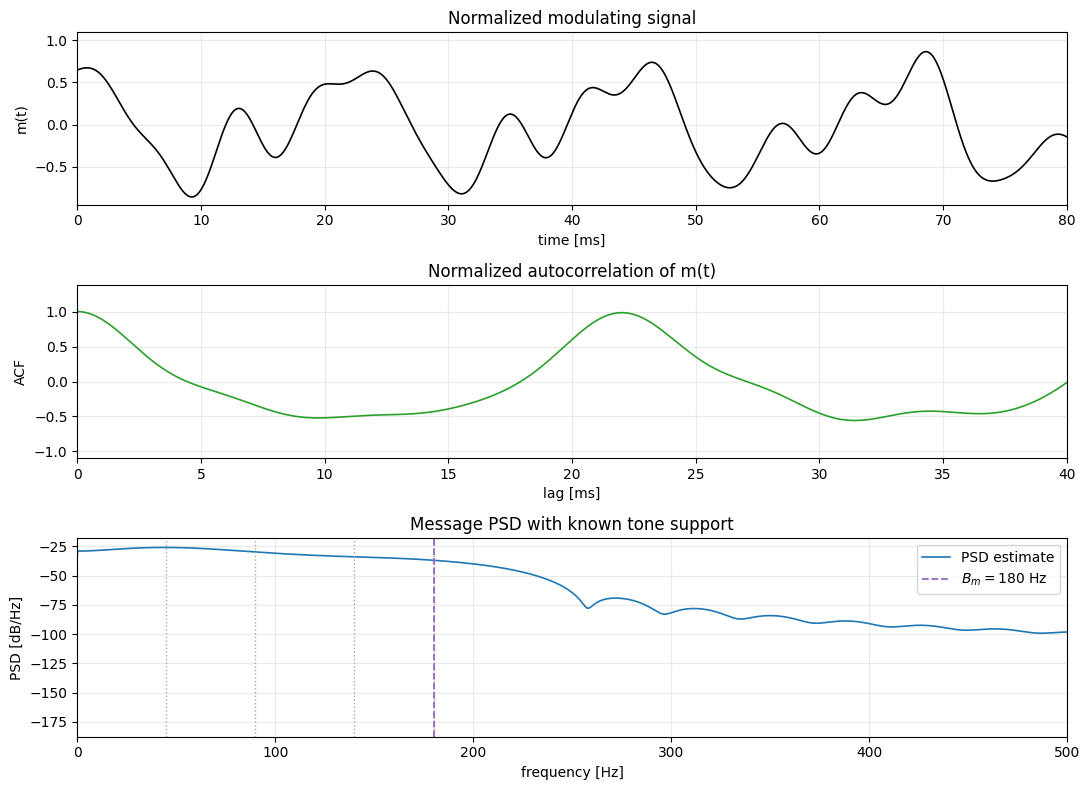

Message theoretical bandwidth B_m = 180.0 Hz
Message 98% occupied bandwidth estimate = 179.9 Hz


In [3]:
time_ms = t * 1_000
lags, acf_m = normalized_autocorrelation(m)
freqs_m, psd_m = welch_psd(m, fs)
bw_m_98, _, _ = occupied_bandwidth_from_psd(m, fs)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), gridspec_kw={"height_ratios": [1.0, 1.0, 1.15]})
axes[0].plot(time_ms, m, color="black", linewidth=1.2)
axes[0].set_title("Normalized modulating signal")
axes[0].set_xlabel("time [ms]")
axes[0].set_ylabel("m(t)")
axes[0].set_xlim(0, 80)
axes[0].grid(True, alpha=0.25)

axes[1].plot(lags * 1_000, acf_m, color="tab:green", linewidth=1.2)
axes[1].set_title("Normalized autocorrelation of m(t)")
axes[1].set_xlabel("lag [ms]")
axes[1].set_ylabel("ACF")
axes[1].set_xlim(0, lag_axis_ms)
axes[1].grid(True, alpha=0.25)

axes[2].plot(freqs_m, db10(psd_m), color="tab:blue", linewidth=1.2, label="PSD estimate")
for freq in message_freqs:
    axes[2].axvline(freq, color="0.65", linestyle=":", linewidth=1.0)
axes[2].axvline(message_bandwidth, color="tab:purple", linestyle="--", linewidth=1.3, label=rf"$B_m={message_bandwidth:g}$ Hz")
axes[2].set_title("Message PSD with known tone support")
axes[2].set_xlabel("frequency [Hz]")
axes[2].set_ylabel("PSD [dB/Hz]")
axes[2].set_xlim(0, 500)
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right")
fig.tight_layout()
plt.show()

print(f"Message theoretical bandwidth B_m = {message_bandwidth:.1f} Hz")
print(f"Message 98% occupied bandwidth estimate = {bw_m_98:.1f} Hz")

## SSB Modulation

Let
$$
m_a(t)=m(t)+j\widehat m(t)
$$
be the analytic message. The upper-sideband suppressed-carrier signal is
$$
s_{USB,SC}(t;\mu)=A_c\mu\left[m(t)\cos(2\pi f_c t)-\widehat m(t)\sin(2\pi f_c t)\right].
$$
The lower-sideband suppressed-carrier signal changes the Hilbert sign:
$$
s_{LSB,SC}(t;\mu)=A_c\mu\left[m(t)\cos(2\pi f_c t)+\widehat m(t)\sin(2\pi f_c t)\right].
$$
Carrier-transmitted SSB simply adds the carrier term:
$$
s_{USB,TC}(t;\mu)=A_c\cos(2\pi f_c t)+s_{USB,SC}(t;\mu).
$$
For the chosen message, the expected occupied passband width of one sideband is approximately $B_m$, not $2B_m$.

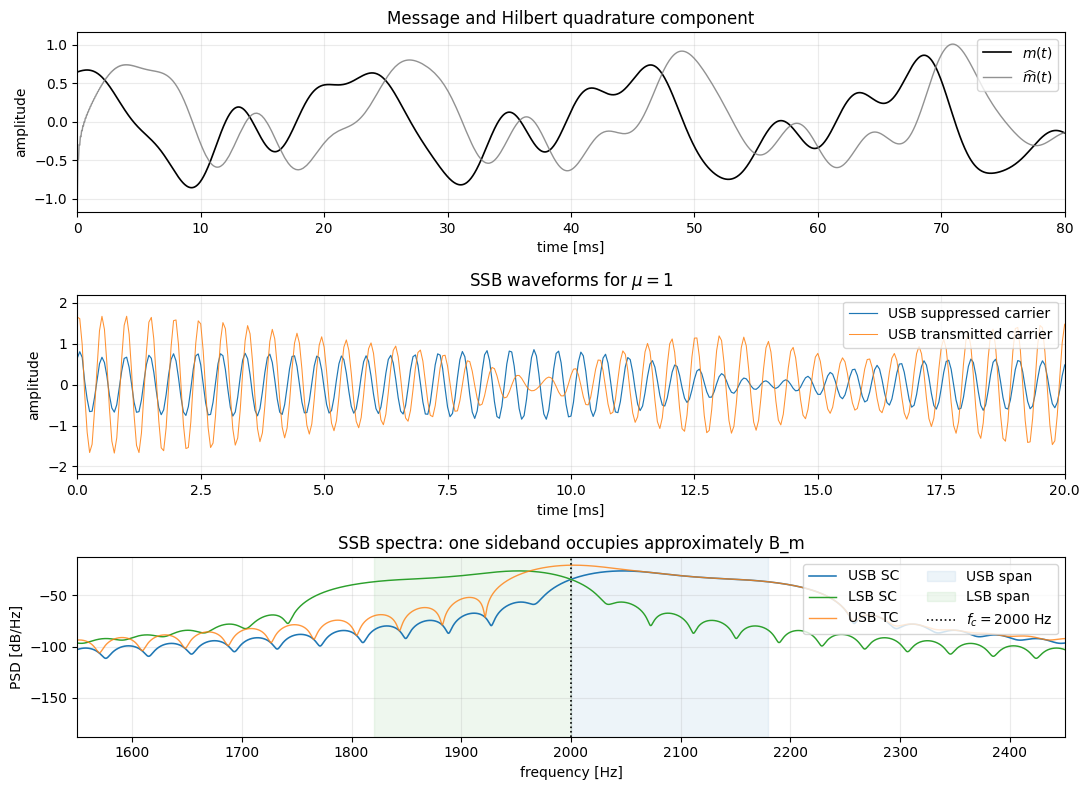

mu=0.72: USB-SC power=0.1047, USB-TC power=0.6047
mu=1: USB-SC power=0.2020, USB-TC power=0.7020
mu=1.23: USB-SC power=0.3056, USB-TC power=0.8056


In [4]:
m_hat = hilbert_transform(m)
carrier_cos = np.cos(2 * np.pi * fc * t)
carrier_sin = np.sin(2 * np.pi * fc * t)

ssb_usb_sc = {}
ssb_lsb_sc = {}
ssb_usb_tc = {}
for mu in mus:
    usb_sc = Ac * mu * (m * carrier_cos - m_hat * carrier_sin)
    lsb_sc = Ac * mu * (m * carrier_cos + m_hat * carrier_sin)
    usb_tc = Ac * carrier_cos + usb_sc
    ssb_usb_sc[mu] = usb_sc
    ssb_lsb_sc[mu] = lsb_sc
    ssb_usb_tc[mu] = usb_tc

mu_example = 1.0
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
axes[0].plot(time_ms, m, color="black", linewidth=1.2, label="$m(t)$")
axes[0].plot(time_ms, m_hat, color="tab:gray", linewidth=1.0, alpha=0.85, label=r"$\widehat m(t)$")
axes[0].set_title("Message and Hilbert quadrature component")
axes[0].set_xlabel("time [ms]")
axes[0].set_ylabel("amplitude")
axes[0].set_xlim(0, 80)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

axes[1].plot(time_ms, ssb_usb_sc[mu_example], color="tab:blue", linewidth=0.85, label="USB suppressed carrier")
axes[1].plot(time_ms, ssb_usb_tc[mu_example], color="tab:orange", linewidth=0.75, alpha=0.85, label="USB transmitted carrier")
axes[1].set_title(rf"SSB waveforms for $\mu={mu_example:g}$")
axes[1].set_xlabel("time [ms]")
axes[1].set_ylabel("amplitude")
axes[1].set_xlim(0, 20)
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

freqs_usb, psd_usb = welch_psd(ssb_usb_sc[mu_example], fs)
freqs_lsb, psd_lsb = welch_psd(ssb_lsb_sc[mu_example], fs)
freqs_tc, psd_tc = welch_psd(ssb_usb_tc[mu_example], fs)
axes[2].plot(freqs_usb, db10(psd_usb), color="tab:blue", linewidth=1.15, label="USB SC")
axes[2].plot(freqs_lsb, db10(psd_lsb), color="tab:green", linewidth=1.05, label="LSB SC")
axes[2].plot(freqs_tc, db10(psd_tc), color="tab:orange", linewidth=1.0, alpha=0.8, label="USB TC")
axes[2].axvspan(fc, fc + message_bandwidth, color="tab:blue", alpha=0.08, label="USB span")
axes[2].axvspan(fc - message_bandwidth, fc, color="tab:green", alpha=0.08, label="LSB span")
axes[2].axvline(fc, color="black", linestyle=":", linewidth=1.2, label=rf"$f_c={fc}$ Hz")
axes[2].set_title("SSB spectra: one sideband occupies approximately B_m")
axes[2].set_xlabel("frequency [Hz]")
axes[2].set_ylabel("PSD [dB/Hz]")
axes[2].set_xlim(fc - 450, fc + 450)
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

for mu in mus:
    power_sc = np.mean(ssb_usb_sc[mu] ** 2)
    power_tc = np.mean(ssb_usb_tc[mu] ** 2)
    print(f"mu={mu:g}: USB-SC power={power_sc:.4f}, USB-TC power={power_tc:.4f}")

## Channel And Demodulators

The AWGN channel is
$$
y(t)=s(t)+n(t),
$$
where the noise variance is selected from the measured transmit-signal power so that the requested SNR is obtained.

Two receiver implementations are compared:

### Conventional coherent low-pass receiver

For synchronized carrier recovery,
$$
r_c(t)=\operatorname{LPF}\{2y(t)\cos(2\pi f_c t)\}.
$$
For suppressed-carrier USB, the low-pass part is $A_c\mu m(t)$. Carrier-transmitted SSB adds a DC term after mixing, so the implementation removes the mean before dividing by $A_c\mu$.

### Hilbert / analytic receiver

The Hilbert receiver computes $y_a(t)=y(t)+j\mathcal{H}\{y(t)\}$ and shifts it to complex baseband:
$$
r_a(t)=\operatorname{LPF}\{y_a(t)e^{-j2\pi f_c t}\}.
$$
For USB, the real part is $A_c\mu m(t)$ after DC removal. This method uses the analytic component directly, so it also exposes the complex baseband representation.

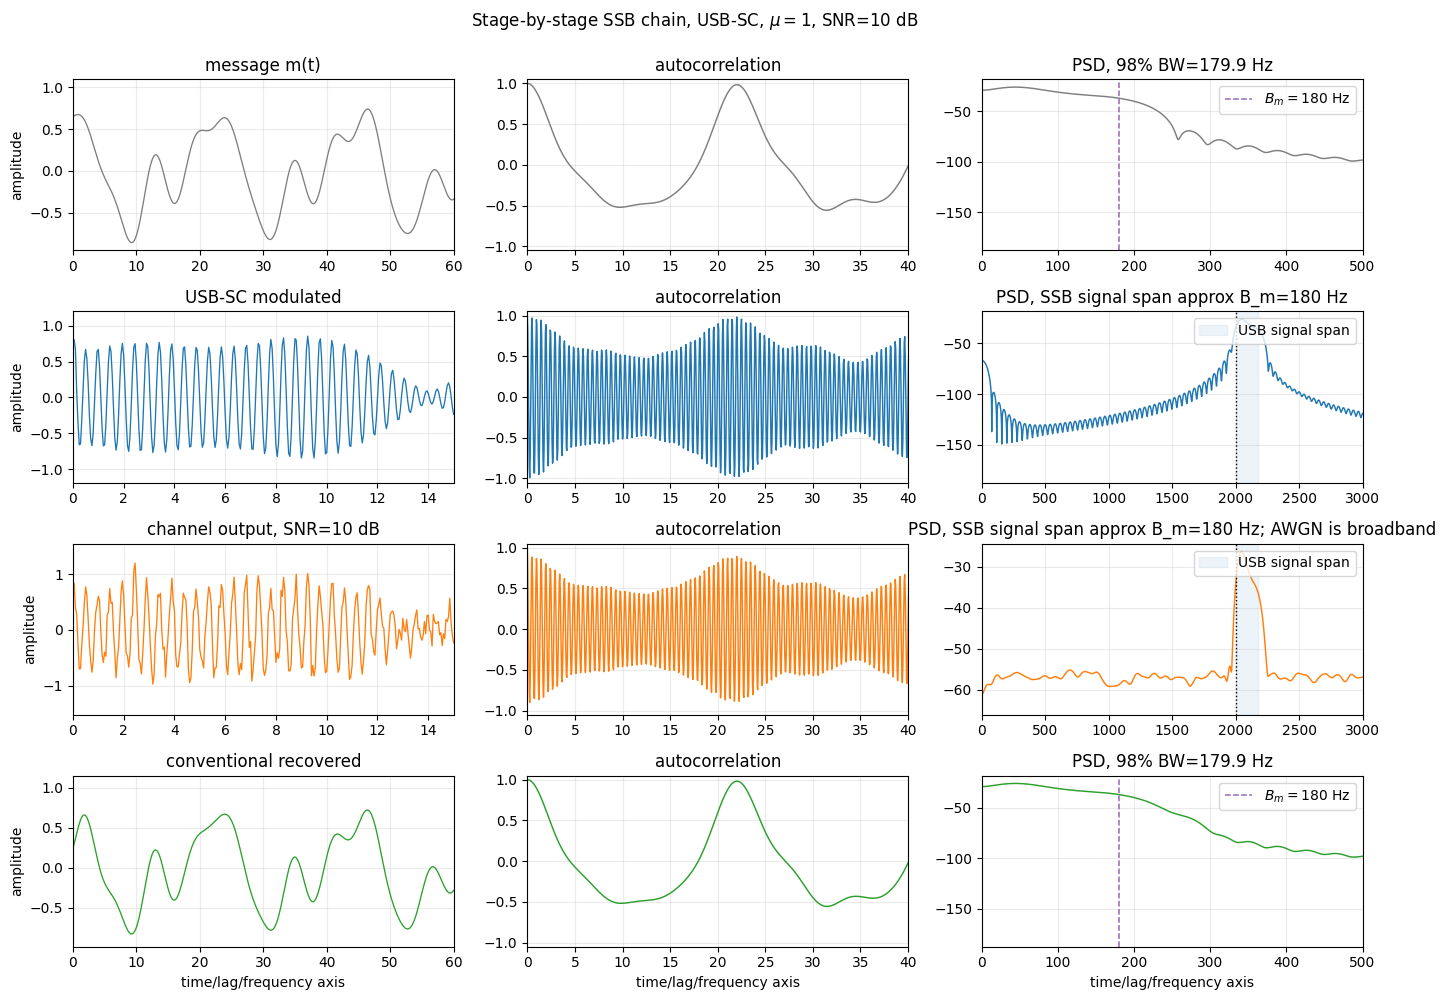

Analysis channel noise power = 0.02020
Conventional RMSE = 0.0434, corr = 0.9955
Hilbert RMSE = 0.0434, corr = 0.9955


In [5]:
def conventional_demodulate(y, mu):
    mixed = 2 * y * carrier_cos
    baseband = lowpass_fft(mixed, fs, cutoff_hz=lowpass_cutoff)
    baseband = np.real(baseband) - np.mean(np.real(baseband))
    return baseband / (Ac * mu)


def hilbert_demodulate_usb(y, mu):
    y_analytic = analytic_signal(y)
    complex_baseband = lowpass_fft(y_analytic * np.exp(-1j * 2 * np.pi * fc * t), fs, cutoff_hz=lowpass_cutoff)
    recovered = np.real(complex_baseband) - np.mean(np.real(complex_baseband))
    return recovered / (Ac * mu), complex_baseband / (Ac * mu)


analysis_mu = 1.0
analysis_snr_db = 10
s_analysis = ssb_usb_sc[analysis_mu]
y_analysis, analysis_noise_power = add_awgn(s_analysis, analysis_snr_db, rng)
m_conv_analysis = conventional_demodulate(y_analysis, analysis_mu)
m_hilbert_analysis, complex_baseband_analysis = hilbert_demodulate_usb(y_analysis, analysis_mu)

stage_signals = [
    ("message m(t)", m, "tab:gray", 500, "baseband"),
    ("USB-SC modulated", s_analysis, "tab:blue", frequency_axis_max, "passband"),
    (rf"channel output, SNR={analysis_snr_db} dB", y_analysis, "tab:orange", frequency_axis_max, "passband_awgn"),
    ("conventional recovered", m_conv_analysis, "tab:green", 500, "baseband"),
]

fig, axes = plt.subplots(len(stage_signals), 3, figsize=(14, 10))
for row, (label, signal, color, x_max, stage_kind) in enumerate(stage_signals):
    lags, acf = normalized_autocorrelation(signal)
    freqs, psd = welch_psd(signal, fs)
    bw_98, _, _ = occupied_bandwidth_from_psd(signal, fs)

    axes[row, 0].plot(time_ms, signal, color=color, linewidth=0.95)
    axes[row, 0].set_title(label)
    axes[row, 0].set_ylabel("amplitude")
    axes[row, 0].set_xlim(0, 60 if row != 1 and row != 2 else 15)
    axes[row, 0].grid(True, alpha=0.25)

    axes[row, 1].plot(lags * 1_000, acf, color=color, linewidth=1.05)
    axes[row, 1].set_title("autocorrelation")
    axes[row, 1].set_xlim(0, lag_axis_ms)
    axes[row, 1].set_ylim(-1.05, 1.05)
    axes[row, 1].grid(True, alpha=0.25)

    axes[row, 2].plot(freqs, db10(psd), color=color, linewidth=1.05)
    if stage_kind == "baseband":
        axes[row, 2].axvline(message_bandwidth, color="tab:purple", linestyle="--", linewidth=1.1, label=rf"$B_m={message_bandwidth:g}$ Hz")
        psd_title = f"PSD, 98% BW={bw_98:.1f} Hz"
    else:
        axes[row, 2].axvspan(fc, fc + message_bandwidth, color="tab:blue", alpha=0.08, label="USB signal span")
        axes[row, 2].axvline(fc, color="black", linestyle=":", linewidth=1.0)
        psd_title = f"PSD, SSB signal span approx B_m={message_bandwidth:g} Hz"
        if stage_kind == "passband_awgn":
            psd_title += "; AWGN is broadband"
    axes[row, 2].set_title(psd_title)
    axes[row, 2].set_xlim(0, x_max)
    axes[row, 2].grid(True, alpha=0.25)
    axes[row, 2].legend(loc="upper right")

for ax in axes[-1, :]:
    ax.set_xlabel("time/lag/frequency axis")
fig.suptitle(rf"Stage-by-stage SSB chain, USB-SC, $\mu={analysis_mu:g}$, SNR={analysis_snr_db} dB", y=0.995)
fig.tight_layout()
plt.show()

print(f"Analysis channel noise power = {analysis_noise_power:.5f}")
print(f"Conventional RMSE = {rmse(m, m_conv_analysis):.4f}, corr = {corrcoef(m, m_conv_analysis):.4f}")
print(f"Hilbert RMSE = {rmse(m, m_hilbert_analysis):.4f}, corr = {corrcoef(m, m_hilbert_analysis):.4f}")

## SNR And Modulation-Factor Sweep

The final numerical experiment uses the USB suppressed-carrier signal for every $\mu$ and SNR pair. This isolates the two receiver methods without envelope-detector ambiguity.

Expected behavior:

- increasing $\mu$ increases sideband signal power before the requested SNR is applied;
- because the channel noise is scaled to the requested SNR, the recovered error should be controlled mainly by SNR, not by $\mu$;
- the conventional and Hilbert receivers should be close when carrier synchronization is exact and the ideal low-pass cutoff contains all message tones;
- both receivers should degrade monotonically as SNR decreases.

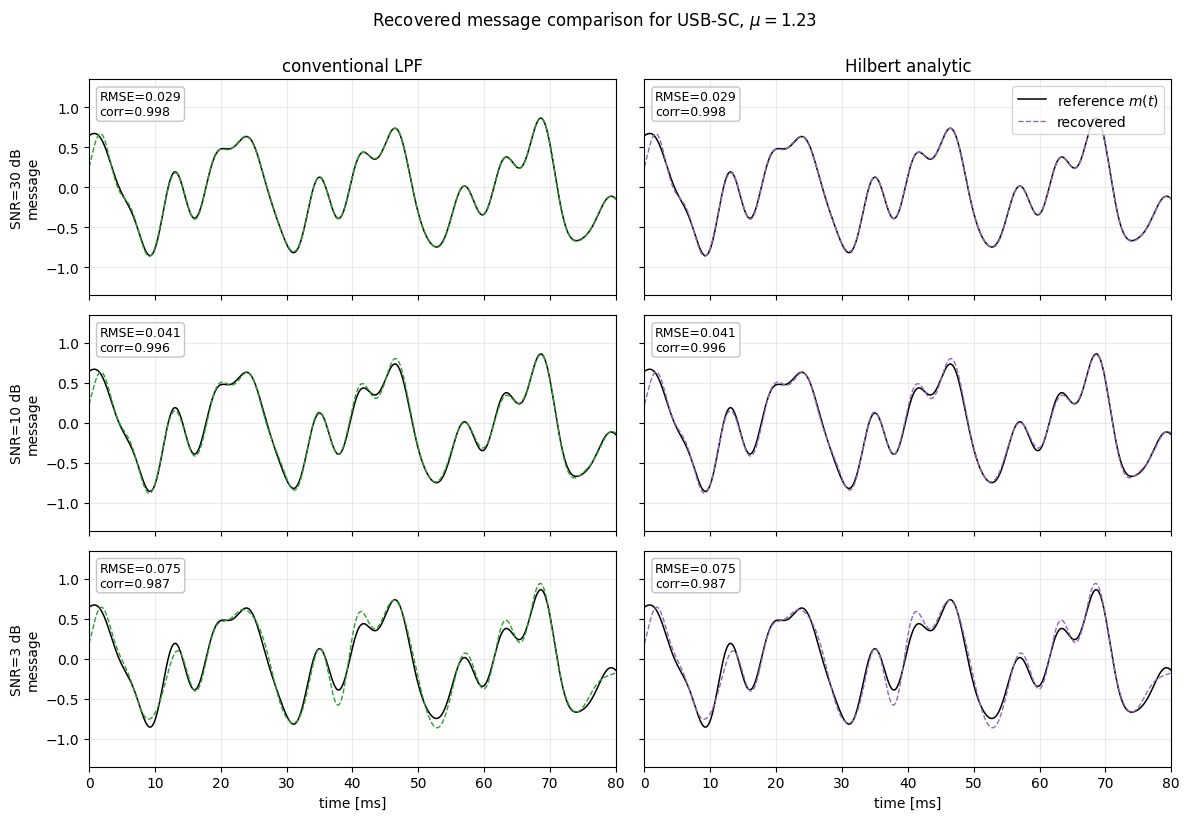

mu=0.72, SNR=30 dB: conv RMSE=0.0290, corr=0.9979, BW98=179.9 Hz; Hilbert RMSE=0.0290, corr=0.9979, BW98=179.9 Hz
mu=0.72, SNR=10 dB: conv RMSE=0.0438, corr=0.9953, BW98=180.1 Hz; Hilbert RMSE=0.0438, corr=0.9953, BW98=180.1 Hz
mu=0.72, SNR= 3 dB: conv RMSE=0.0668, corr=0.9889, BW98=180.2 Hz; Hilbert RMSE=0.0668, corr=0.9889, BW98=180.2 Hz
mu=1, SNR=30 dB: conv RMSE=0.0290, corr=0.9979, BW98=179.9 Hz; Hilbert RMSE=0.0290, corr=0.9979, BW98=179.9 Hz
mu=1, SNR=10 dB: conv RMSE=0.0428, corr=0.9955, BW98=180.2 Hz; Hilbert RMSE=0.0428, corr=0.9955, BW98=180.2 Hz
mu=1, SNR= 3 dB: conv RMSE=0.0679, corr=0.9887, BW98=180.2 Hz; Hilbert RMSE=0.0679, corr=0.9887, BW98=180.2 Hz
mu=1.23, SNR=30 dB: conv RMSE=0.0289, corr=0.9979, BW98=179.9 Hz; Hilbert RMSE=0.0289, corr=0.9979, BW98=179.9 Hz
mu=1.23, SNR=10 dB: conv RMSE=0.0410, corr=0.9958, BW98=179.9 Hz; Hilbert RMSE=0.0410, corr=0.9958, BW98=179.9 Hz
mu=1.23, SNR= 3 dB: conv RMSE=0.0745, corr=0.9867, BW98=180.1 Hz; Hilbert RMSE=0.0745, corr=0.986

In [6]:
sweep_rng = np.random.default_rng(31415)
sweep_results = {}

for mu in mus:
    sweep_results[mu] = {}
    signal = ssb_usb_sc[mu]
    for snr_db in snr_db_values:
        y, noise_power = add_awgn(signal, snr_db, sweep_rng)
        rec_conv = conventional_demodulate(y, mu)
        rec_hilbert, complex_bb = hilbert_demodulate_usb(y, mu)
        bw_conv, _, _ = occupied_bandwidth_from_psd(rec_conv, fs)
        bw_hilbert, _, _ = occupied_bandwidth_from_psd(rec_hilbert, fs)
        sweep_results[mu][snr_db] = {
            "y": y,
            "noise_power": noise_power,
            "conv": rec_conv,
            "hilbert": rec_hilbert,
            "conv_rmse": rmse(m, rec_conv),
            "hilbert_rmse": rmse(m, rec_hilbert),
            "conv_corr": corrcoef(m, rec_conv),
            "hilbert_corr": corrcoef(m, rec_hilbert),
            "conv_bw_98": bw_conv,
            "hilbert_bw_98": bw_hilbert,
        }

fig, axes = plt.subplots(len(snr_db_values), 2, figsize=(12, 8.2), sharex=True, sharey=True)
plot_mu = 1.23
for row, snr_db in enumerate(snr_db_values):
    result = sweep_results[plot_mu][snr_db]
    for col, (method, color) in enumerate([("conv", "tab:green"), ("hilbert", "tab:purple")]):
        ax = axes[row, col]
        recovered = result[method]
        ax.plot(time_ms, m, color="black", linewidth=1.1, label="reference $m(t)$")
        ax.plot(time_ms, recovered, color=color, linewidth=1.0, linestyle="--", label="recovered")
        ax.text(
            0.02,
            0.95,
            f"RMSE={result[method + '_rmse']:.3f}\ncorr={result[method + '_corr']:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.75", "alpha": 0.9},
        )
        if row == 0:
            ax.set_title("conventional LPF" if method == "conv" else "Hilbert analytic")
        if col == 0:
            ax.set_ylabel(f"SNR={snr_db} dB\nmessage")
        if row == len(snr_db_values) - 1:
            ax.set_xlabel("time [ms]")
        ax.set_xlim(0, 80)
        ax.set_ylim(-1.35, 1.35)
        ax.grid(True, alpha=0.25)
axes[0, 1].legend(loc="upper right")
fig.suptitle(rf"Recovered message comparison for USB-SC, $\mu={plot_mu:g}$", y=0.995)
fig.tight_layout()
plt.show()

for mu in mus:
    for snr_db in snr_db_values:
        result = sweep_results[mu][snr_db]
        print(
            f"mu={mu:g}, SNR={snr_db:>2} dB: "
            f"conv RMSE={result['conv_rmse']:.4f}, corr={result['conv_corr']:.4f}, BW98={result['conv_bw_98']:.1f} Hz; "
            f"Hilbert RMSE={result['hilbert_rmse']:.4f}, corr={result['hilbert_corr']:.4f}, BW98={result['hilbert_bw_98']:.1f} Hz"
        )

## Final Comparison

The summary below compares the two demodulators across the full $\mu\times\mathrm{SNR}$ grid. Under the ideal assumptions used here, both receivers are valid:

- the conventional receiver works because the local oscillator is synchronized and the low-pass cutoff includes all message tones;
- the Hilbert receiver works because the analytic passband signal can be shifted directly to complex baseband;
- neither receiver depends on envelope detection, so the SSB suppressed-carrier chain is not subject to the DSB-LC over-modulation criterion;
- noise sensitivity is governed primarily by SNR, while $\mu$ acts as a transmit sideband scale in this controlled experiment.

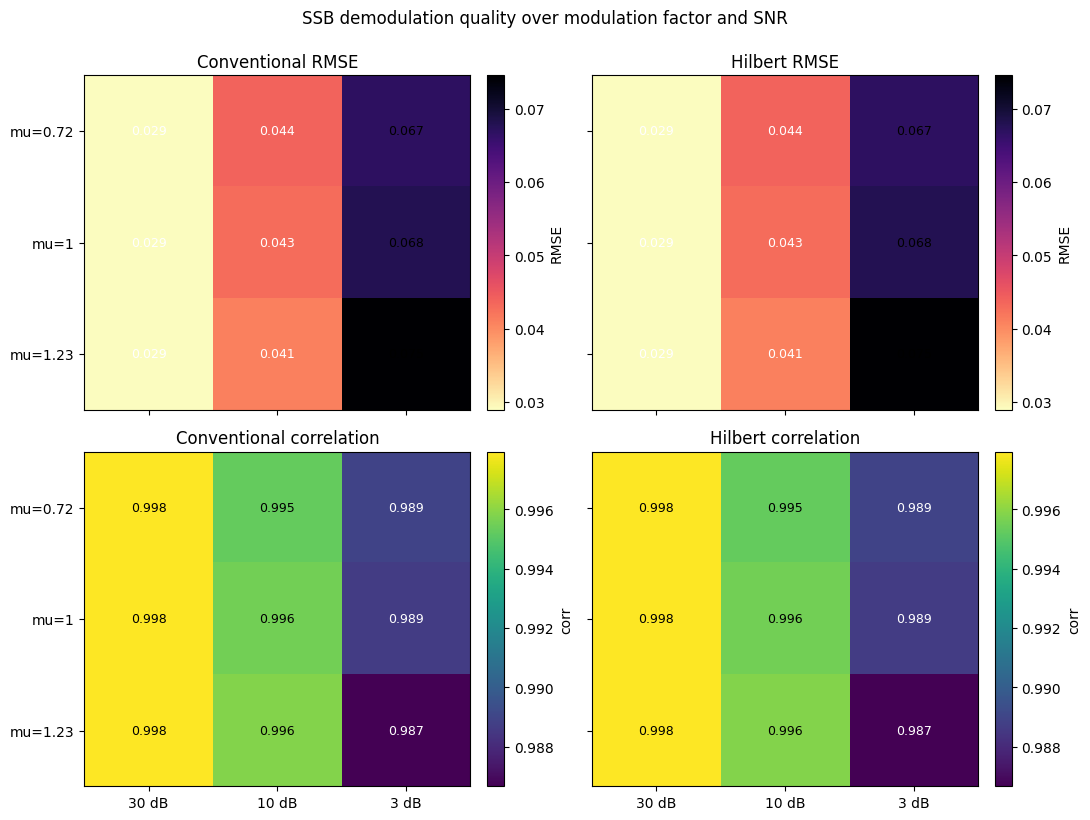

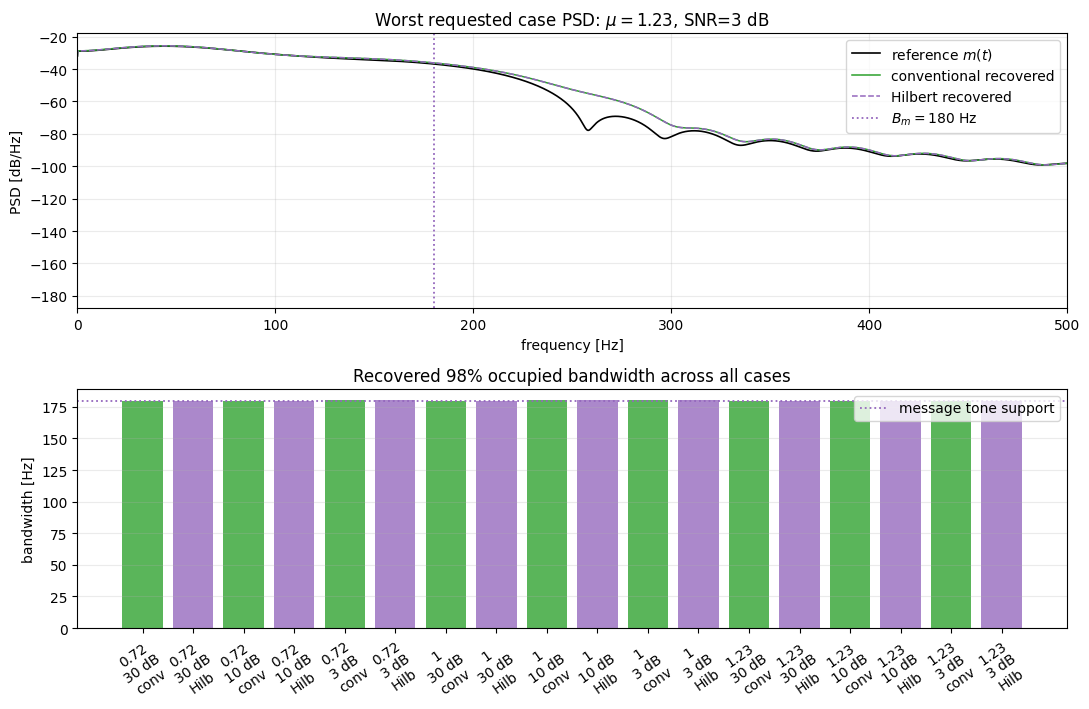

mu=0.72, SNR=30 dB: numerically tied, RMSE difference conv-Hilbert = -4.8572e-17
mu=0.72, SNR=10 dB: numerically tied, RMSE difference conv-Hilbert = +1.3878e-16
mu=0.72, SNR= 3 dB: numerically tied, RMSE difference conv-Hilbert = +1.8041e-15
mu=1, SNR=30 dB: numerically tied, RMSE difference conv-Hilbert = +1.7000e-16
mu=1, SNR=10 dB: numerically tied, RMSE difference conv-Hilbert = -1.7347e-16
mu=1, SNR= 3 dB: numerically tied, RMSE difference conv-Hilbert = +1.4433e-15
mu=1.23, SNR=30 dB: numerically tied, RMSE difference conv-Hilbert = -7.2858e-17
mu=1.23, SNR=10 dB: numerically tied, RMSE difference conv-Hilbert = +1.2351e-15
mu=1.23, SNR= 3 dB: numerically tied, RMSE difference conv-Hilbert = +3.5527e-15
All recovered BW98 values stay near the message support B_m=180.0 Hz, as expected after ideal low-pass demodulation with cutoff 243.0 Hz.


In [7]:
conv_rmse_grid = np.array([[sweep_results[mu][snr]["conv_rmse"] for snr in snr_db_values] for mu in mus])
hilbert_rmse_grid = np.array([[sweep_results[mu][snr]["hilbert_rmse"] for snr in snr_db_values] for mu in mus])
conv_corr_grid = np.array([[sweep_results[mu][snr]["conv_corr"] for snr in snr_db_values] for mu in mus])
hilbert_corr_grid = np.array([[sweep_results[mu][snr]["hilbert_corr"] for snr in snr_db_values] for mu in mus])

fig, axes = plt.subplots(2, 2, figsize=(11, 8.2), sharex=True, sharey=True)
grids = [
    (conv_rmse_grid, "Conventional RMSE", "magma_r", "RMSE"),
    (hilbert_rmse_grid, "Hilbert RMSE", "magma_r", "RMSE"),
    (conv_corr_grid, "Conventional correlation", "viridis", "corr"),
    (hilbert_corr_grid, "Hilbert correlation", "viridis", "corr"),
]
for ax, (grid, title, cmap, label) in zip(axes.flat, grids):
    im = ax.imshow(grid, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(len(snr_db_values)), [f"{snr} dB" for snr in snr_db_values])
    ax.set_yticks(range(len(mus)), [f"mu={mu:g}" for mu in mus])
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="white" if grid[i, j] < np.mean(grid) else "black", fontsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label)
fig.suptitle("SSB demodulation quality over modulation factor and SNR", y=0.995)
fig.tight_layout()
plt.show()

worst_mu = mus[-1]
worst_snr = snr_db_values[-1]
worst = sweep_results[worst_mu][worst_snr]
freqs_ref, psd_ref = welch_psd(m, fs)
freqs_conv, psd_conv = welch_psd(worst["conv"], fs)
freqs_hilbert, psd_hilbert = welch_psd(worst["hilbert"], fs)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), gridspec_kw={"height_ratios": [1.15, 1.0]})
axes[0].plot(freqs_ref, db10(psd_ref), color="black", linewidth=1.2, label="reference $m(t)$")
axes[0].plot(freqs_conv, db10(psd_conv), color="tab:green", linewidth=1.1, label="conventional recovered")
axes[0].plot(freqs_hilbert, db10(psd_hilbert), color="tab:purple", linewidth=1.1, linestyle="--", label="Hilbert recovered")
axes[0].axvline(message_bandwidth, color="tab:purple", linestyle=":", linewidth=1.3, label=rf"$B_m={message_bandwidth:g}$ Hz")
axes[0].set_title(rf"Worst requested case PSD: $\mu={worst_mu:g}$, SNR={worst_snr} dB")
axes[0].set_xlabel("frequency [Hz]")
axes[0].set_ylabel("PSD [dB/Hz]")
axes[0].set_xlim(0, 500)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

bar_labels = []
bar_values = []
bar_colors = []
for mu in mus:
    for snr_db in snr_db_values:
        bar_labels.extend([f"{mu:g}\n{snr_db} dB\nconv", f"{mu:g}\n{snr_db} dB\nHilb"])
        bar_values.extend([sweep_results[mu][snr_db]["conv_bw_98"], sweep_results[mu][snr_db]["hilbert_bw_98"]])
        bar_colors.extend(["tab:green", "tab:purple"])
axes[1].bar(bar_labels, bar_values, color=bar_colors, alpha=0.78)
axes[1].axhline(message_bandwidth, color="tab:purple", linestyle=":", linewidth=1.3, label="message tone support")
axes[1].set_title("Recovered 98% occupied bandwidth across all cases")
axes[1].set_ylabel("bandwidth [Hz]")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

for mu in mus:
    for snr_db in snr_db_values:
        result = sweep_results[mu][snr_db]
        diff = result["conv_rmse"] - result["hilbert_rmse"]
        if abs(diff) < 1e-10:
            comparison = "numerically tied"
        else:
            comparison = "Hilbert lower RMSE" if diff > 0 else "conventional lower RMSE"
        print(f"mu={mu:g}, SNR={snr_db:>2} dB: {comparison}, RMSE difference conv-Hilbert = {diff:+.4e}")

print(f"All recovered BW98 values stay near the message support B_m={message_bandwidth:.1f} Hz, as expected after ideal low-pass demodulation with cutoff {lowpass_cutoff:.1f} Hz.")